# Serie temporali: temperatura media mensile a Sydney

**Obiettivo**: analizzare e prevedere l'andamento della temperatura pomeridiana (`Temp3pm`)
di una singola località (Sydney), aggregata su base mensile.

**Protocollo.** Il notebook separa in modo rigoroso sviluppo e valutazione:

1. la serie mensile viene costruita e **divisa subito** in training (tutti i mesi tranne gli
   ultimi 24) e test (ultimi 24 mesi);
2. **tutte le scelte di modello** (analisi esplorativa, test di stazionarietà, correlogrammi,
   termine deterministico, ordini, famiglia di modelli) usano **solo il training**;
3. il confronto fra famiglie di modelli avviene con una **validazione a origine mobile**
   interna al training;
4. il test viene usato **una sola volta**, alla fine, per stimare l'errore del modello scelto;
5. il modello scelto viene infine riaddestrato sull'intera serie per prevedere i 12 mesi
   successivi.

In [141]:
import itertools
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

# statsmodels emette molti avvisi di convergenza durante le ricerche su griglia e la
# validazione: vengono silenziati qui, ma i casi di mancata convergenza sono CONTATI
# esplicitamente dove servono (ricerca a griglia).
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Cartella in cui salvare le figure usate nella relazione
IMG_DIR = Path("images")
IMG_DIR.mkdir(exist_ok=True)

def salva(nome):
    plt.savefig(IMG_DIR / f"{nome}.png", dpi=150, bbox_inches="tight")

In [142]:
def load_dataset(filename="weatherAUS.csv", cartella="dataset"):
    for base in [Path.cwd(), *Path.cwd().parents]:
        file = base / cartella / filename
        if file.exists():
            return file
    raise FileNotFoundError(
        f"'{cartella}/{filename}' non trovato. Scarica il dataset da Kaggle "
        f"e mettilo nella cartella '{cartella}/' nella root del progetto.")

DATA_PATH = load_dataset()
df = pd.read_csv(DATA_PATH, parse_dates=["Date"], na_values="NA")

## Parametri

In [143]:
LOCALITA  = "Sydney"
VARIABILE = "Temp3pm"
EXOG_VARS = ["Humidity3pm", "Pressure3pm"]

N_TEST = 24      # mesi di test: due cicli stagionali completi
S      = 12      # periodo stagionale (dati mensili)

# Validazione a origine mobile interna al training
H_CV    = 12     # orizzonte di previsione di ogni fold (un ciclo annuale)
N_FOLD  = 5      # numero di origini
STEP_CV = 6      # distanza in mesi fra due origini consecutive

N_FUTURO = 12    # mesi da prevedere oltre la fine della serie

# gestione della deprecazione pandas "M" -> "ME"
FREQ = "ME"
try:
    pd.Series(dtype=float, index=pd.DatetimeIndex([])).resample(FREQ)
except ValueError:
    FREQ = "M"

## Costruzione della serie mensile

La serie giornaliera di Sydney viene aggregata con la media mensile. Si controllano poi i mesi
privi di osservazioni e il numero di giorni che compone ciascuna media.

In [144]:
serie_giorn = (df[df["Location"] == LOCALITA]
               .set_index("Date")[VARIABILE].sort_index())
serie_raw = serie_giorn.resample(FREQ).mean()

print(f"{LOCALITA} | {VARIABILE}")
print("Periodo:", serie_raw.index.min().date(), "->", serie_raw.index.max().date())
print("Mesi totali:", len(serie_raw), "| mesi mancanti:", int(serie_raw.isna().sum()))
print("Mesi mancanti:", [d.strftime("%Y-%m") for d in serie_raw[serie_raw.isna()].index])

# Un mese con pochi giorni osservati darebbe una media poco affidabile
n_giorni = serie_giorn.resample(FREQ).count()
n_oss = n_giorni[n_giorni > 0]
print(f"\nGiorni osservati per mese (mesi non vuoti): mediana {n_oss.median():.0f}, "
      f"min {n_oss.min()}, max {n_oss.max()}")
pochi = n_oss[n_oss < 10]
if len(pochi):
    print(f"ATTENZIONE: {len(pochi)} mesi con meno di 10 osservazioni giornaliere:")
    print(pochi.to_string())
else:
    print("Nessun mese con meno di 10 osservazioni: le medie mensili sono affidabili.")

Sydney | Temp3pm
Periodo: 2008-02-29 -> 2017-06-30
Mesi totali: 113 | mesi mancanti: 3
Mesi mancanti: ['2011-04', '2012-12', '2013-02']

Giorni osservati per mese (mesi non vuoti): mediana 31, min 25, max 31
Nessun mese con meno di 10 osservazioni: le medie mensili sono affidabili.


## Suddivisione in training e test, e imputazione

Lo split avviene **prima di qualsiasi analisi**, così che nessuna scelta successiva possa
dipendere, anche indirettamente, dai mesi di test.

I mesi mancanti vengono imputati con interpolazione temporale **sul solo training**.
L'interpolazione usa anche il punto successivo al mese mancante: se un buco cadesse a ridosso
del confine, verrebbe ricostruito con un valore del test. Un controllo automatico verifica che
nessun mese mancante cada nel periodo di test.

Training: 89 mesi (2008-02 -> 2015-06)
Test    : 24 mesi (2015-07 -> 2017-06)
Serie completa: min 16.1 C, max 27.3 C, media 21.6 C


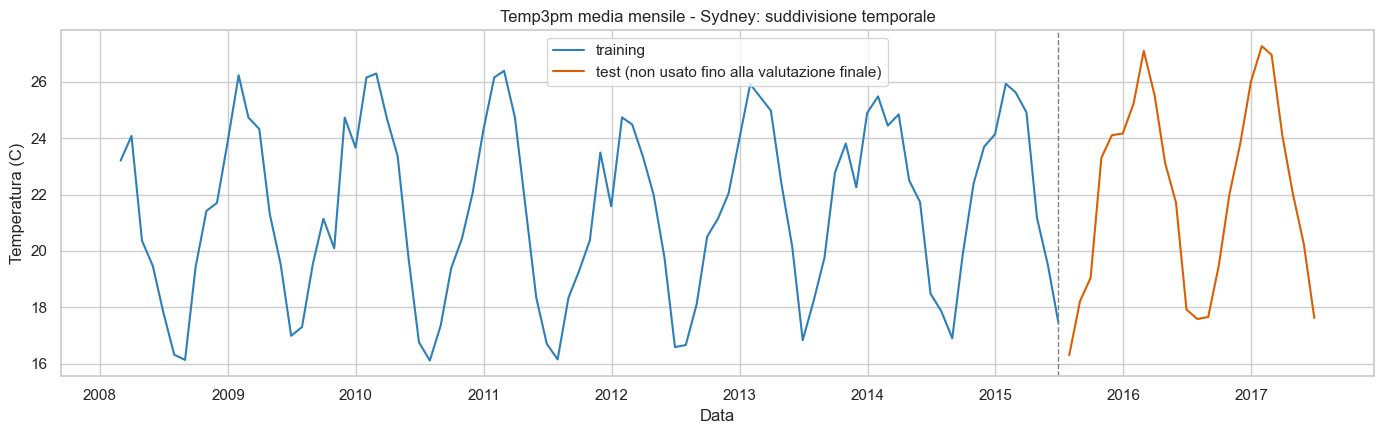

In [145]:
mesi_mancanti = serie_raw[serie_raw.isna()].index
inizio_test   = serie_raw.index[-N_TEST]
assert (mesi_mancanti < inizio_test).all(), \
    "Ci sono mesi mancanti nel periodo di test: l'imputazione introdurrebbe lookahead."

train = serie_raw.iloc[:-N_TEST].interpolate(method="time")
test  = serie_raw.iloc[-N_TEST:]
assert train.notna().all() and test.notna().all()

# serie completa (training imputato + test), usata SOLO per il modello finale
serie = pd.concat([train, test])

print(f"Training: {len(train)} mesi ({train.index.min():%Y-%m} -> {train.index.max():%Y-%m})")
print(f"Test    : {len(test)} mesi ({test.index.min():%Y-%m} -> {test.index.max():%Y-%m})")
print(f"Serie completa: min {serie.min():.1f} C, max {serie.max():.1f} C, media {serie.mean():.1f} C")

plt.figure(figsize=(14, 4.5))
plt.plot(train.index, train.values, label="training", color="#2C7FB8")
plt.plot(test.index, test.values, label="test (non usato fino alla valutazione finale)",
         color="#D95F02")
plt.axvline(train.index[-1], color="grey", ls="--", lw=1)
plt.title(f"{VARIABILE} media mensile - {LOCALITA}: suddivisione temporale")
plt.xlabel("Data"); plt.ylabel("Temperatura (C)"); plt.legend()
plt.tight_layout(); salva("split"); plt.show()

## Analisi esplorativa (solo training)

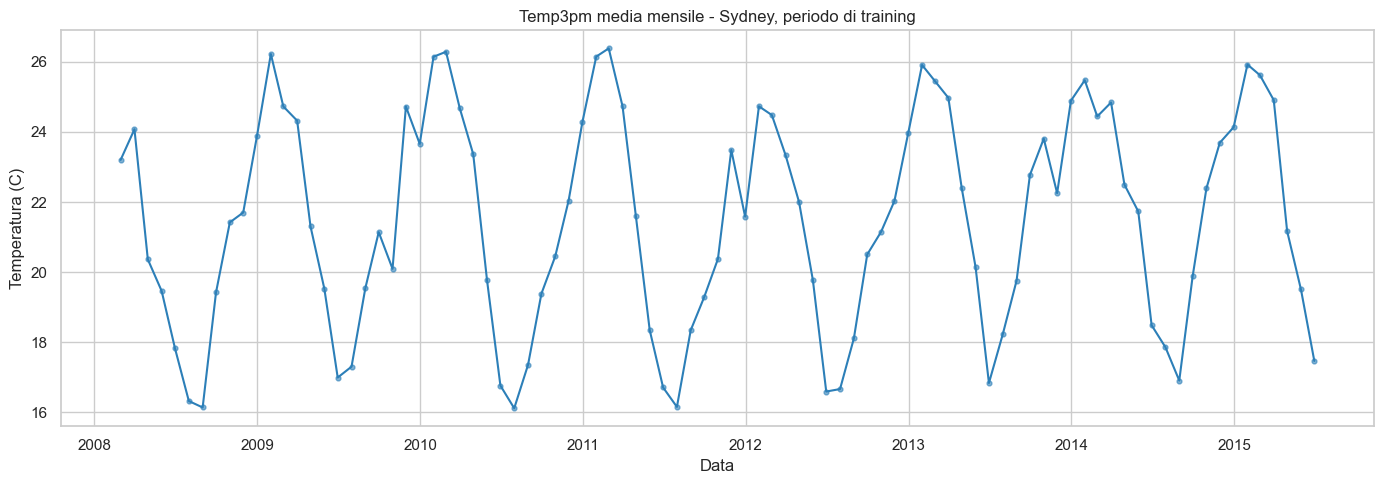

In [146]:
plt.figure(figsize=(14, 5))
plt.plot(train.index, train.values, color="#2C7FB8", lw=1.5)
plt.scatter(train.index, train.values, s=12, color="#2C7FB8", alpha=.6)
plt.title(f"{VARIABILE} media mensile - {LOCALITA}, periodo di training")
plt.xlabel("Data"); plt.ylabel("Temperatura (C)")
plt.tight_layout(); salva("temp_annuale"); plt.show()

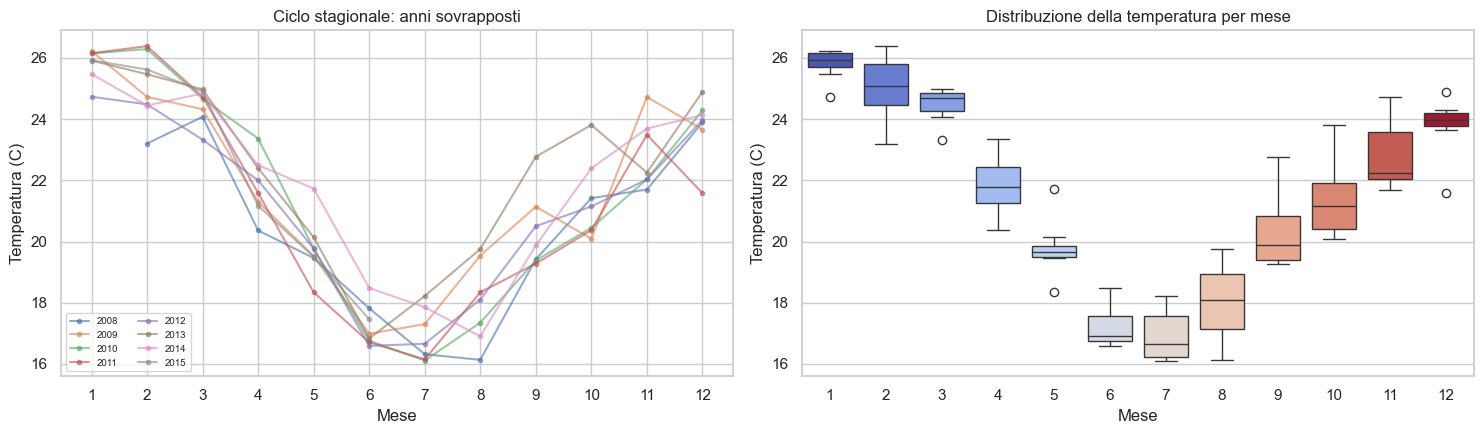

In [147]:
tmp = pd.DataFrame({"valore": train.values}, index=train.index)
tmp["anno"], tmp["mese"] = tmp.index.year, tmp.index.month

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for anno, g in tmp.groupby("anno"):
    axes[0].plot(g["mese"], g["valore"], marker="o", ms=3, alpha=.6, label=str(anno))
axes[0].set_title("Ciclo stagionale: anni sovrapposti")
axes[0].set_xlabel("Mese"); axes[0].set_ylabel("Temperatura (C)")
axes[0].set_xticks(range(1, 13)); axes[0].legend(fontsize=7, ncol=2)

sns.boxplot(data=tmp, x="mese", y="valore", hue="mese", palette="coolwarm",
            legend=False, ax=axes[1])
axes[1].set_title("Distribuzione della temperatura per mese")
axes[1].set_xlabel("Mese"); axes[1].set_ylabel("Temperatura (C)")
plt.tight_layout(); salva("ciclo_annuale"); plt.show()

### Decomposizione e verifica della forma additiva

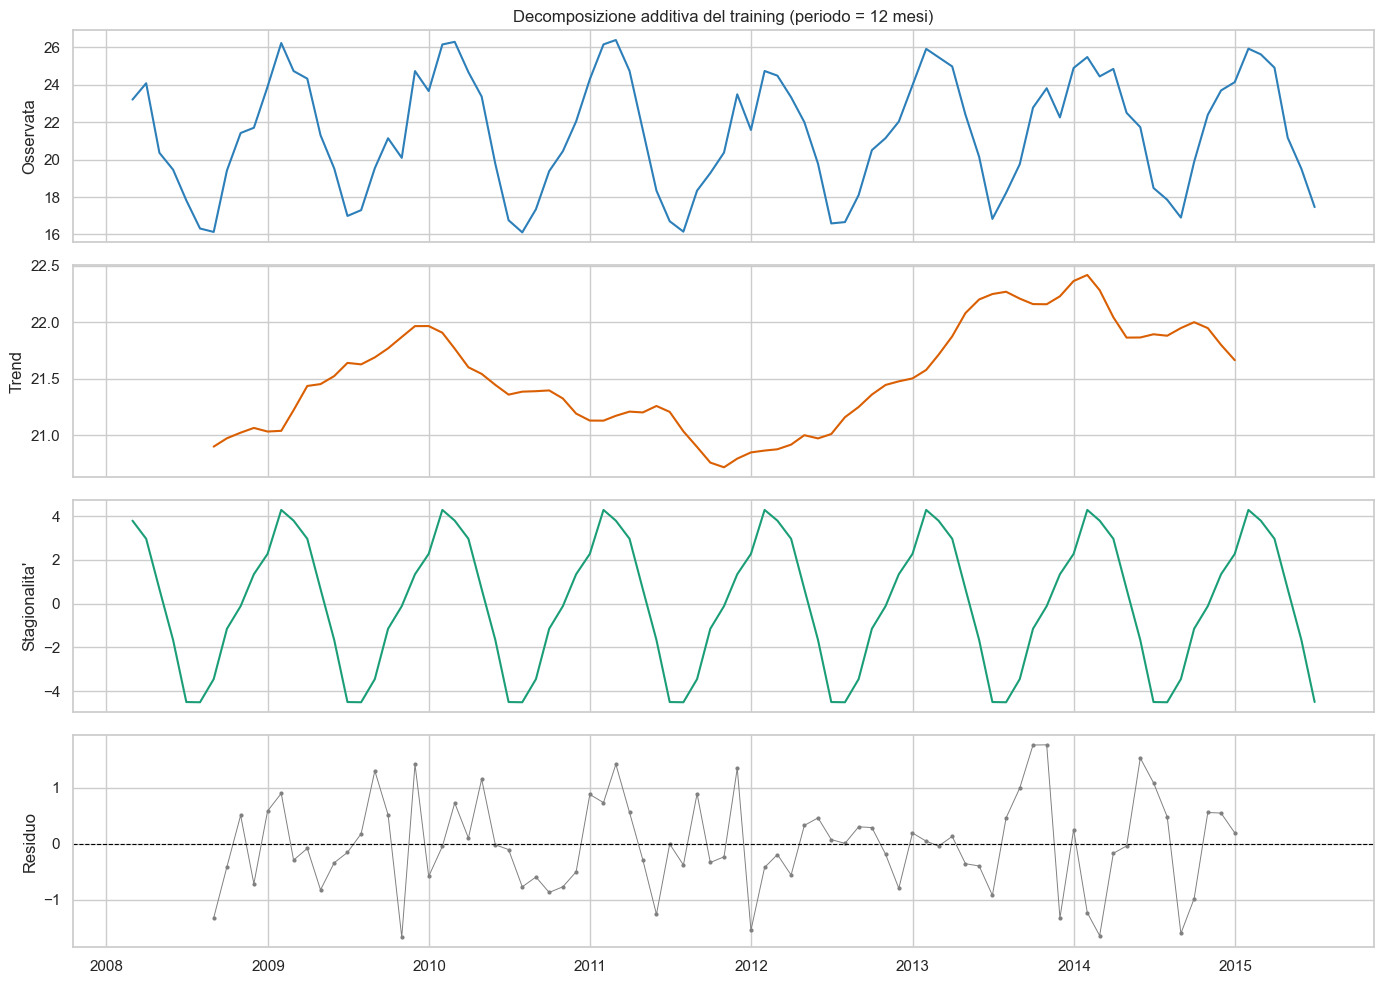

Ampiezza del ciclo stagionale: 8.8 C
Trend: da 20.7 a 22.4 C (escursione 1.7 C)
Deviazione standard del residuo: 0.82 C

Dispersione dei residui: prima meta' 0.781 | seconda meta' 0.865 | rapporto 1.11
Dev. std residui: additiva 0.8192 | moltiplicativa (riscalata) 0.8469
--> Dispersione stabile e residuo additivo non superiore: si adotta la forma ADDITIVA.


In [148]:
dec = seasonal_decompose(train, model="additive", period=S)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(dec.observed, color="#2C7FB8"); axes[0].set_ylabel("Osservata")
axes[1].plot(dec.trend,    color="#D95F02"); axes[1].set_ylabel("Trend")
axes[2].plot(dec.seasonal, color="#1B9E77"); axes[2].set_ylabel("Stagionalita'")
axes[3].plot(dec.resid, color="grey", marker="o", ms=2, lw=.7); axes[3].set_ylabel("Residuo")
axes[3].axhline(0, color="black", lw=.8, ls="--")
axes[0].set_title("Decomposizione additiva del training (periodo = 12 mesi)")
plt.tight_layout(); salva("decomposizione"); plt.show()

ampiezza = dec.seasonal.max() - dec.seasonal.min()
tr_valido = dec.trend.dropna()
print(f"Ampiezza del ciclo stagionale: {ampiezza:.1f} C")
print(f"Trend: da {tr_valido.min():.1f} a {tr_valido.max():.1f} C "
      f"(escursione {tr_valido.max() - tr_valido.min():.1f} C)")
print(f"Deviazione standard del residuo: {dec.resid.std():.2f} C")

# --- additiva o moltiplicativa? -------------------------------------------------------
# (a) la dispersione dei residui cresce nel tempo? (b) quale residuo è più piccolo?
r = dec.resid.dropna()
meta = len(r) // 2
sd_prima, sd_dopo = r.iloc[:meta].std(), r.iloc[meta:].std()
rapporto = sd_dopo / sd_prima

dec_m  = seasonal_decompose(train, model="multiplicative", period=S)
sd_add = r.std()
sd_mul = (dec_m.resid.dropna() * train.mean()).std()   # riportata alla stessa scala

print(f"\nDispersione dei residui: prima meta' {sd_prima:.3f} | seconda meta' {sd_dopo:.3f} "
      f"| rapporto {rapporto:.2f}")
print(f"Dev. std residui: additiva {sd_add:.4f} | moltiplicativa (riscalata) {sd_mul:.4f}")

stabile, piu_netta = 0.7 < rapporto < 1.4, sd_add <= sd_mul
if stabile and piu_netta:
    print("--> Dispersione stabile e residuo additivo non superiore: si adotta la forma ADDITIVA.")
elif not stabile:
    print("--> La dispersione varia nel tempo: valutare la forma MOLTIPLICATIVA.")
else:
    print("--> Dispersione stabile ma residuo additivo superiore: le due forme sono equivalenti.")

## Stazionarietà (solo training)

ADF e KPSS hanno ipotesi nulle opposte (ADF: radice unitaria; KPSS: stazionarietà), per cui si
considerano solide solo le conclusioni su cui concordano. I test vengono ripetuti dopo la
differenziazione stagionale.

NB: `statsmodels` satura il p-value del KPSS nell'intervallo [0,01; 0,10]; un valore pari a
0,10 va letto come "≥ 0,10".

In [149]:
def test_stazionarieta(x, nome):
    adf_stat, adf_p = adfuller(x.dropna())[:2]
    kpss_stat, kpss_p = kpss(x.dropna(), regression="c", nlags="auto")[:2]
    return {"Serie": nome,
            "ADF stat": round(adf_stat, 3), "ADF p": round(adf_p, 3),
            "ADF esito": "stazionaria" if adf_p < 0.05 else "radice unitaria non rifiutata",
            "KPSS stat": round(kpss_stat, 3), "KPSS p": round(kpss_p, 3),
            "KPSS esito": "non stazionaria" if kpss_p < 0.05 else "stazionarieta' non rifiutata"}

train_d12 = train.diff(S).dropna()
tab_staz = pd.DataFrame([test_stazionarieta(train, "Training originale"),
                         test_stazionarieta(train_d12, "Training differenziato (lag 12)")]
                        ).set_index("Serie")
p_adf_d, p_kpss_d = tab_staz.iloc[1]["ADF p"], tab_staz.iloc[1]["KPSS p"]
if p_adf_d < 0.05 and p_kpss_d >= 0.05:
    print("Dopo la differenziazione i due test concordano sulla stazionarieta'.")
elif p_kpss_d >= 0.05:
    print(f"Dopo la differenziazione: KPSS non rifiuta la stazionarietà, ADF al limite "
          f"(p = {p_adf_d:.3f}). Conclusione non netta: la scelta D=1 va verificata (§11).")
else:
    print("ATTENZIONE: il KPSS rifiuta la stazionarietà anche dopo la differenziazione.")
tab_staz

Dopo la differenziazione: KPSS non rifiuta la stazionarietà, ADF al limite (p = 0.059). Conclusione non netta: la scelta D=1 va verificata (§11).


,ADF stat,ADF p,ADF esito,KPSS stat,KPSS p,KPSS esito
Serie,,,,,,
Training originale,-1.567,0.500,radice unitaria non rifiutata,0.059,0.1,stazionarieta' non rifiutata
Training differenziato (lag 12),-2.797,0.059,radice unitaria non rifiutata,0.140,0.1,stazionarieta' non rifiutata


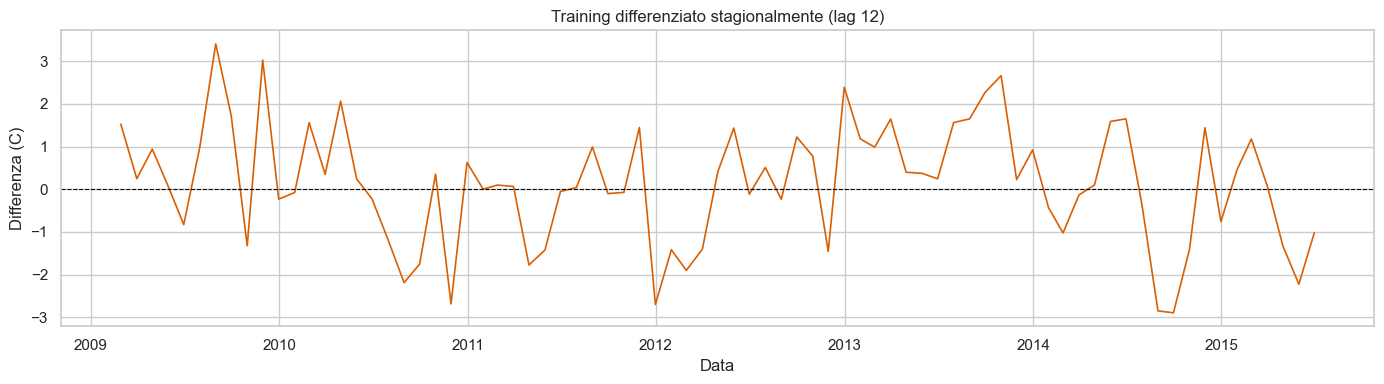

In [150]:
plt.figure(figsize=(14, 4))
plt.plot(train_d12.index, train_d12.values, color="#D95F02", lw=1.2)
plt.axhline(0, color="black", lw=.8, ls="--")
plt.title("Training differenziato stagionalmente (lag 12)")
plt.xlabel("Data"); plt.ylabel("Differenza (C)")
plt.tight_layout(); salva("serie_differenziata"); plt.show()

**Lettura.** Sulla serie originale i due test tipicamente non concordano: è il sintomo di una
stagionalità forte, che nessuno dei due gestisce in modo esplicito. Dopo la differenziazione
stagionale il KPSS non deve rifiutare la stazionarietà e l'ADF dovrebbe rifiutare la radice
unitaria. Se l'ADF risulta solo al limite della significatività, va ricordato che su poco più di
70 osservazioni il test ha bassa potenza: la scelta `D = 1` si appoggia allora anche
sull'andamento della serie differenziata e sul rapido decadimento dell'ACF, e viene
comunque messa alla prova nella validazione a origine mobile, dove il SARIMA è confrontato con modelli che non
differenziano la serie. Non si applica differenziazione ordinaria (`d = 0`), perché il KPSS
sulla serie originale non rileva un trend stocastico.

## Identificazione degli ordini con ACF e PACF (solo training)

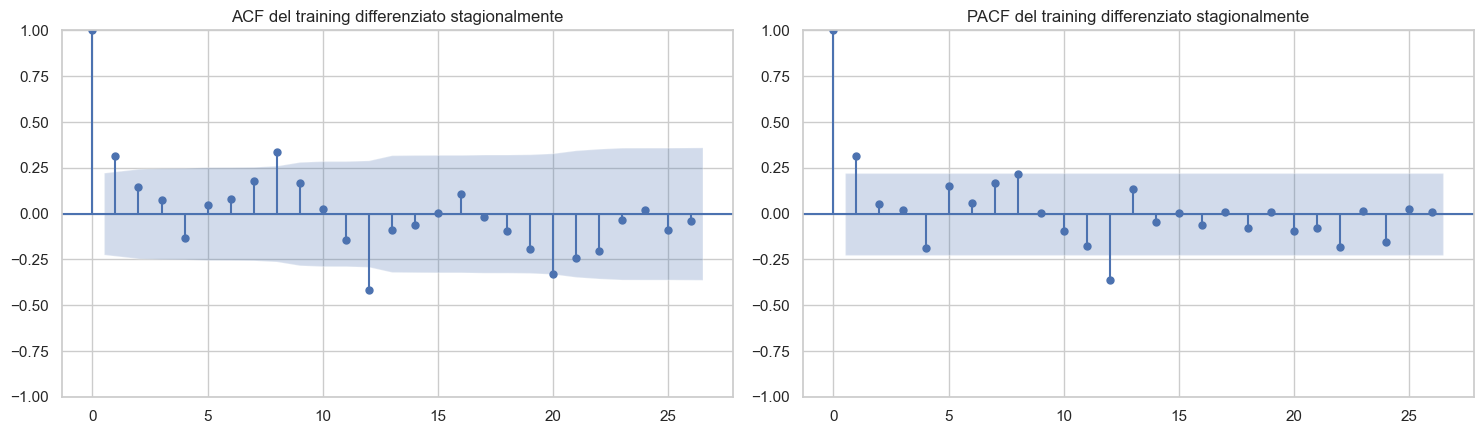

Banda di significatività approssimata: +/-0.223
lag  1: ACF +0.316 | PACF +0.316
lag  2: ACF +0.145 | PACF +0.050
lag 12: ACF -0.415 | PACF -0.364
lag 24: ACF +0.017 | PACF -0.153


In [151]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
plot_acf(train_d12, lags=26, ax=axes[0])
axes[0].set_title("ACF del training differenziato stagionalmente")
plot_pacf(train_d12, lags=26, ax=axes[1], method="ywm")
axes[1].set_title("PACF del training differenziato stagionalmente")
plt.tight_layout(); salva("acf_pacf"); plt.show()

# valori ai ritardi chiave, per la lettura nel testo
from statsmodels.tsa.stattools import acf, pacf
a, p_ = acf(train_d12, nlags=24), pacf(train_d12, nlags=24, method="ywm")
banda = 1.96 / np.sqrt(len(train_d12))
print(f"Banda di significatività approssimata: +/-{banda:.3f}")
for k in [1, 2, 12, 24]:
    print(f"lag {k:2d}: ACF {a[k]:+.3f} | PACF {p_[k]:+.3f}")

**Lettura attesa dei correlogrammi.**

- Parte non stagionale: un picco significativo al ritardo 1 con la PACF che rientra subito
  nelle bande indica una componente **AR(1)**, quindi `p = 1`; in assenza di un troncamento
  netto dell'ACF si pone inizialmente `q = 0`.
- Parte stagionale: un picco negativo al ritardo 12 nell'ACF, non più significativo al 24,
  indica una componente **MA stagionale** di ordine 1, quindi `Q = 1`, `P = 0`.

Ordini di partenza: **SARIMA(1,0,0)(0,1,1)₁₂**. I correlogrammi individuano modelli plausibili,
che vengono poi confrontati numericamente.

In [152]:
ORDER_MANUALE  = (1, 0, 0)       # (p, d, q)
SORDER_MANUALE = (0, 1, 1, S)    # (P, D, Q, s)

## Termine deterministico (solo training)

Con `d = 0` e `D = 1` il default di `SARIMAX` è `trend="n"`: nessuna costante. Sulla serie
differenziata stagionalmente questo impone che la variazione media da un anno al successivo sia
nulla. Con `trend="c"` il modello stima invece una **deriva**, cioè una variazione media annua.

La scelta viene fatta **sul solo training**, confrontando i due modelli per AIC (stessa
differenziazione, quindi AIC confrontabili) e osservando la media della serie differenziata.

In [153]:
righe = []
for tr in ["n", "c"]:
    m = SARIMAX(train, order=ORDER_MANUALE, seasonal_order=SORDER_MANUALE,
                trend=tr).fit(disp=False)
    righe.append({"trend": tr, "AIC": round(m.aic, 1), "BIC": round(m.bic, 1)})
tab_trend = pd.DataFrame(righe).set_index("trend")
print(tab_trend.to_string())

media_d12 = train_d12.mean()
se_d12 = train_d12.std() / np.sqrt(len(train_d12))
print(f"\nMedia del training differenziato: {media_d12:+.3f} C (errore standard {se_d12:.3f})")

TREND = tab_trend["AIC"].idxmin()
print(f"--> Termine deterministico scelto per AIC sul training: trend='{TREND}'")

         AIC    BIC
trend              
n      238.6  245.6
c      236.5  245.9

Media del training differenziato: +0.122 C (errore standard 0.160)
--> Termine deterministico scelto per AIC sul training: trend='c'


## Confronto dei candidati e ricerca a griglia (solo training)

Tutti i modelli hanno la stessa differenziazione (`d = 0`, `D = 1`) e lo stesso termine
deterministico, quindi gli AIC sono confrontabili. I vincoli di stazionarietà e invertibilità
restano attivi.

In [154]:
candidati = [
    ((1, 0, 0), (0, 1, 1, S)),   # <- proposto da ACF/PACF
    ((0, 0, 1), (0, 1, 1, S)),
    ((1, 0, 1), (0, 1, 1, S)),
    ((1, 0, 0), (1, 1, 0, S)),
    ((2, 0, 0), (1, 1, 1, S)),
    ((1, 0, 1), (1, 1, 0, S)),
]
righe = []
for order, sorder in candidati:
    m = SARIMAX(train, order=order, seasonal_order=sorder, trend=TREND).fit(disp=False)
    righe.append({"Modello": f"{order}{sorder[:3]}_{sorder[3]}",
                  "AIC": round(m.aic, 1), "BIC": round(m.bic, 1)})
pd.DataFrame(righe).sort_values("AIC").set_index("Modello")

,AIC,BIC
Modello,,
"(1, 0, 0)(0, 1, 1)_12",236.5,245.9
"(0, 0, 1)(0, 1, 1)_12",237.6,247.0
"(1, 0, 1)(0, 1, 1)_12",237.9,249.6
"(2, 0, 0)(1, 1, 1)_12",239.7,253.7
"(1, 0, 1)(1, 1, 0)_12",246.4,258.1
"(1, 0, 0)(1, 1, 0)_12",246.8,256.2


In [155]:
# Ricerca esaustiva: p, q in {0,1,2}, P, Q in {0,1}, con d=0, D=1, s=12 e trend fissati
best_aic, best_cfg, n_tot, n_non_conv = np.inf, None, 0, 0
for p, q, P, Q in itertools.product(range(3), range(3), range(2), range(2)):
    order, sorder = (p, 0, q), (P, 1, Q, S)
    n_tot += 1
    try:
        m = SARIMAX(train, order=order, seasonal_order=sorder, trend=TREND).fit(disp=False)
    except Exception:
        n_non_conv += 1
        continue
    if not m.mle_retvals.get("converged", True):
        n_non_conv += 1
    if np.isfinite(m.aic) and m.aic < best_aic:
        best_aic, best_cfg = m.aic, (order, sorder)

ORDER, SORDER = best_cfg
print(f"Combinazioni stimate: {n_tot} | senza convergenza piena: {n_non_conv}")
print(f"Ordini selezionati dalla griglia: {ORDER}{SORDER} | AIC = {best_aic:.3f}")
print("Coincidono con quelli dei correlogrammi:",
      (ORDER, SORDER) == (ORDER_MANUALE, SORDER_MANUALE))

Combinazioni stimate: 36 | senza convergenza piena: 1
Ordini selezionati dalla griglia: (1, 0, 0)(0, 1, 1, 12) | AIC = 236.497
Coincidono con quelli dei correlogrammi: True


## Stima del modello SARIMA selezionato (solo training)

In [156]:
sarima = SARIMAX(train, order=ORDER, seasonal_order=SORDER, trend=TREND).fit(disp=False)
print(sarima.summary().tables[1])

phi = sarima.params.get("ar.L1", np.nan)
theta_s = sarima.params.get(f"ma.S.L{S}", np.nan)
if np.isfinite(phi):
    print(f"\nAR(1) = {phi:+.3f} -> condizione di stazionarieta' |phi| < 1: "
          f"{'rispettata' if abs(phi) < 1 else 'VIOLATA'}")
if np.isfinite(theta_s):
    print(f"MA stagionale = {theta_s:+.3f}")
    if theta_s < -0.95:
        print("--> Coefficiente al bordo dell'invertibilità: errore standard non affidabile.")
        print("    Con Theta = -1 il fattore (1 - B^12) a destra annulla la differenza")
        print("    stagionale a sinistra: il modello equivale a un ciclo stagionale FISSO")
        print("    più un trend lineare (dalla deriva). L'ipotesi viene verificata nella")
        print("    validazione, confrontando il SARIMA con modelli a stagionalità deterministica.")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0947      0.058      1.627      0.104      -0.019       0.209
ar.L1          0.2917      0.108      2.694      0.007       0.079       0.504
ma.S.L12      -0.9983     38.377     -0.026      0.979     -76.216      74.219
sigma2         0.8336     31.938      0.026      0.979     -61.764      63.431

AR(1) = +0.292 -> condizione di stazionarieta' |phi| < 1: rispettata
MA stagionale = -0.998
--> Coefficiente al bordo dell'invertibilità: errore standard non affidabile.
    Con Theta = -1 il fattore (1 - B^12) a destra annulla la differenza
    stagionale a sinistra: il modello equivale a un ciclo stagionale FISSO
    più un trend lineare (dalla deriva). L'ipotesi viene verificata nella
    validazione, confrontando il SARIMA con modelli a stagionalità deterministica.


## Diagnostica dei residui (solo training)

Nel ciclo di Box-Jenkins la diagnostica segue la stima e precede l'uso del modello per la
previsione. Il test di Ljung-Box viene applicato:

- escludendo i primi 12 residui, che riflettono l'inizializzazione della differenza stagionale;
- correggendo i gradi di libertà (`model_df`) per i parametri stimati diversi dalla varianza.

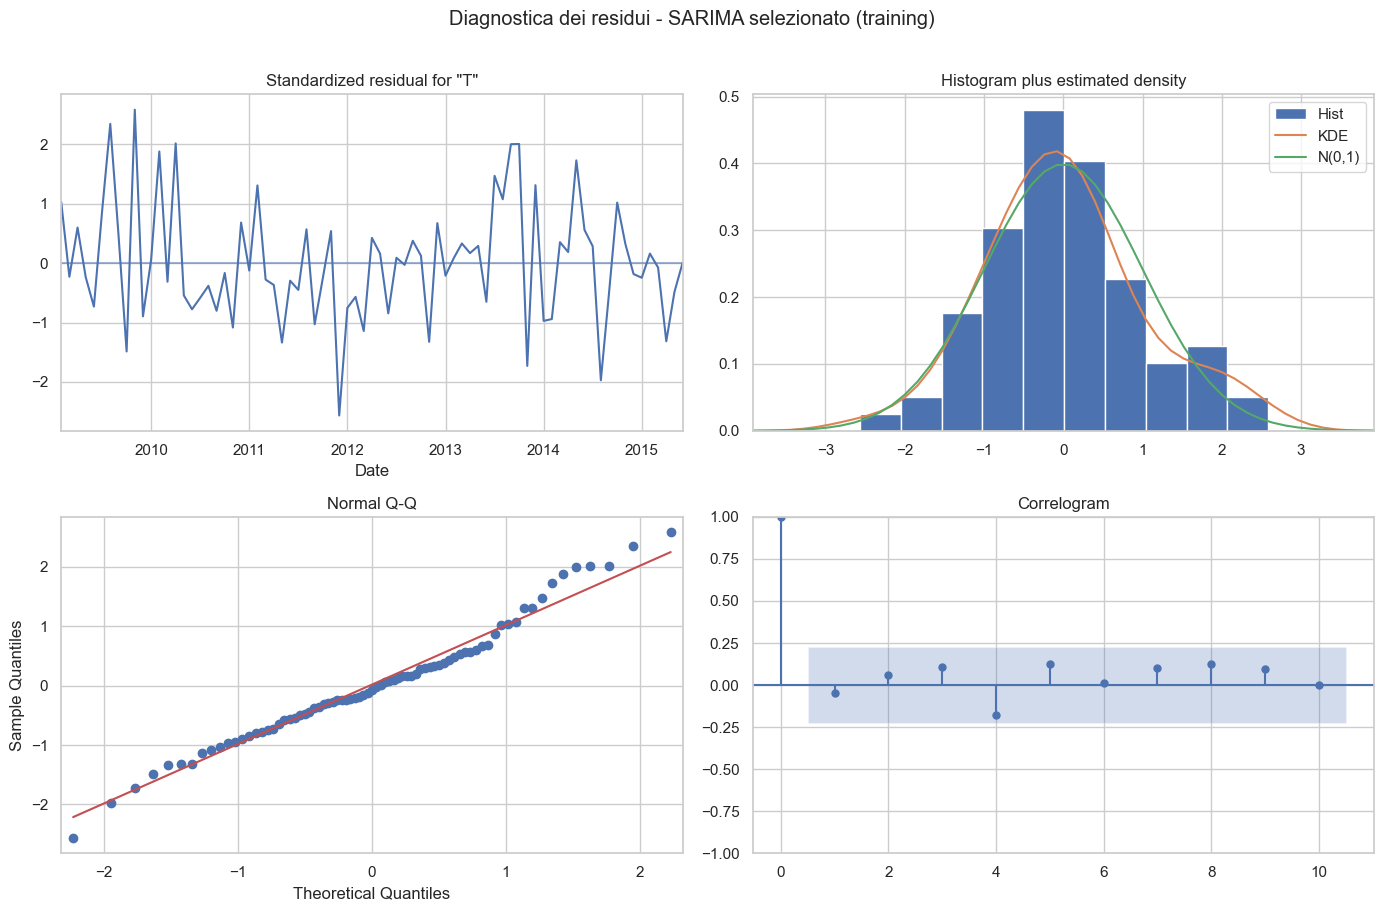

In [157]:
sarima.plot_diagnostics(figsize=(14, 9))
plt.suptitle("Diagnostica dei residui - SARIMA selezionato (training)", y=1.01)
plt.tight_layout(); salva("diagnostica_residui"); plt.show()

In [158]:
SKIP = S
resid = sarima.resid[SKIP:]
k_par = sum(1 for n in sarima.params.index if n != "sigma2")

lb = acorr_ljungbox(resid, lags=[6, 12, 18, 24], model_df=k_par, return_df=True)
print(f"Ljung-Box (H0: residui indipendenti) - model_df = {k_par}")
print(lb.round(4).to_string())
print(f"\nMedia dei residui: {resid.mean():+.3f} | deviazione standard: {resid.std():.3f}")
print("Esito:", "nessuna autocorrelazione residua rilevata" if (lb["lb_pvalue"] > 0.05).all()
      else "ATTENZIONE: autocorrelazione residua a qualche ritardo")

lb_grezzo = acorr_ljungbox(sarima.resid, lags=[12], model_df=k_par, return_df=True)
print(f"\n[Controprova] senza escludere i residui iniziali: p(lag 12) = "
      f"{lb_grezzo['lb_pvalue'].iloc[0]:.4f}")

Ljung-Box (H0: residui indipendenti) - model_df = 3
    lb_stat  lb_pvalue
6    5.9381     0.1147
12   9.6705     0.3778
18  10.2245     0.8054
24  17.8672     0.6574

Media dei residui: +0.032 | deviazione standard: 1.108
Esito: nessuna autocorrelazione residua rilevata

[Controprova] senza escludere i residui iniziali: p(lag 12) = 0.0000


## Validazione a origine mobile (solo training)

L'AIC confronta modelli con la stessa differenziazione, ma non può confrontare il SARIMA
(`D = 1`) con modelli a stagionalità deterministica (`D = 0`), perché le verosimiglianze sono
calcolate su dati diversi. Per confrontare famiglie diverse serve una misura di **errore di
previsione**, che non può però essere calcolata sul test senza trasformarlo in un insieme di
selezione.

Si usa quindi una **validazione a origine mobile** interna al training: il modello viene
addestrato sui primi $n_i$ mesi e prevede i 12 successivi, per 5 origini distanziate di 6 mesi.
L'ultimo fold termina esattamente alla fine del training.

**Modelli confrontati**

| Modello | Ruolo | Stagionalità | Termine deterministico |
|---|---|---|---|
| SARIMA selezionato | candidato | differenziata (`D = 1`) | come scelto al §7 |
| AR(1) + dummy mensili + trend | candidato | 12 dummy (livello incluso) | trend lineare |
| AR(1) + Fourier K=2 + trend | candidato | 4 termini di Fourier | costante + trend lineare |
| SARIMA + esogene previste | candidato | differenziata | come §7 |
| SARIMA senza costante | variante diagnostica | differenziata | nessuno |
| AR(1) + Fourier K=2 senza trend | variante diagnostica | 4 termini di Fourier | sola costante |
| Baseline naïve stagionale | riferimento | ripete gli ultimi 12 mesi | — |

I **candidati** sono le famiglie fra cui si sceglie il modello finale. Le **varianti
diagnostiche** tolgono il termine deterministico a un candidato: non partecipano alla scelta,
ma servono a separare l'effetto della rappresentazione della stagionalità da quello del trend.

**Regola di scelta (fissata prima di vedere i risultati).** Si calcola il MAE medio sui fold e
si individua il candidato migliore. Per ogni altro candidato si calcola la differenza di MAE
rispetto al migliore fold per fold, con il relativo errore standard (confronto **appaiato**,
perché tutti i modelli sono valutati sugli stessi fold). Fra i candidati la cui differenza media
non supera un errore standard (regola dell'*one standard error*), si sceglie quello con **meno
parametri**: differenze di questa entità non sono distinguibili dal rumore della validazione, e
a parità di errore il modello più parsimonioso è preferibile.

In [159]:
def fourier(index, start, K=2, period=S):
    # 't' continua da 'start', cosi' i termini futuri proseguono la stessa fase
    t = np.arange(start, start + len(index))
    return pd.DataFrame({f"{f}{k}": (np.sin if f == "sin" else np.cos)(2 * np.pi * k * t / period)
                         for k in range(1, K + 1) for f in ("sin", "cos")}, index=index)

def dummy_mesi(index):
    d = pd.get_dummies(index.month, prefix="m").astype(float)
    d.index = index
    return d.reindex(columns=[f"m_{i}" for i in range(1, 13)], fill_value=0.0)

def indice_futuro(y, h):
    return pd.date_range(y.index[-1] + pd.offsets.MonthEnd(1), periods=h, freq=FREQ)

# Esogene mensili, allineate all'indice della serie grezza
exog_raw = (df[df["Location"] == LOCALITA].set_index("Date")[EXOG_VARS]
            .sort_index().resample(FREQ).mean().reindex(serie_raw.index))

def exog_passato(fine):
    # esogene fino al mese 'fine' escluso, imputate usando SOLO quel periodo
    return exog_raw.iloc[:fine].interpolate(method="time").ffill().bfill()

def naive_stagionale(y, h):
    return np.resize(y.values[-S:], h)

def adatta_e_prevedi(nome, y, h):
    # Addestra il modello 'nome' sulla serie y e prevede h passi.
    # Restituisce (previsione, modello, n. parametri). Nessun dato successivo a y è usato.
    idx_f = indice_futuro(y, h)
    if nome == "Baseline naive stagionale":
        return naive_stagionale(y, h), None, 0
    if nome == "SARIMA selezionato":
        m = SARIMAX(y, order=ORDER, seasonal_order=SORDER, trend=TREND).fit(disp=False)
        return m.get_forecast(h).predicted_mean.values, m, len(m.params)
    if nome == "SARIMA senza costante":
        m = SARIMAX(y, order=ORDER, seasonal_order=SORDER, trend="n").fit(disp=False)
        return m.get_forecast(h).predicted_mean.values, m, len(m.params)
    if nome == "AR(1) + dummy mensili + trend":
        # le 12 dummy forniscono gia' il livello: niente costante, solo trend lineare
        m = SARIMAX(y, exog=dummy_mesi(y.index), order=(1, 0, 0), trend="t").fit(disp=False)
        return (m.get_forecast(h, exog=dummy_mesi(idx_f)).predicted_mean.values, m,
                len(m.params))
    if nome == "AR(1) + Fourier K=2 + trend":
        m = SARIMAX(y, exog=fourier(y.index, 0), order=(1, 0, 0), trend="ct").fit(disp=False)
        return (m.get_forecast(h, exog=fourier(idx_f, len(y))).predicted_mean.values, m,
                len(m.params))
    if nome == "AR(1) + Fourier K=2 senza trend":
        m = SARIMAX(y, exog=fourier(y.index, 0), order=(1, 0, 0), trend="c").fit(disp=False)
        return (m.get_forecast(h, exog=fourier(idx_f, len(y))).predicted_mean.values, m,
                len(m.params))
    if nome == "SARIMA + esogene previste":
        ex_y = exog_passato(len(y))
        ex_f = pd.DataFrame({c: naive_stagionale(ex_y[c], h) for c in EXOG_VARS}, index=idx_f)
        m = SARIMAX(y, exog=ex_y, order=ORDER, seasonal_order=SORDER,
                    trend=TREND).fit(disp=False)
        return m.get_forecast(h, exog=ex_f).predicted_mean.values, m, len(m.params)
    raise ValueError(nome)

CANDIDATI = ["SARIMA selezionato", "AR(1) + dummy mensili + trend",
             "AR(1) + Fourier K=2 + trend", "SARIMA + esogene previste"]
DIAGNOSTICI = ["SARIMA senza costante", "AR(1) + Fourier K=2 senza trend"]
MODELLI = CANDIDATI + DIAGNOSTICI + ["Baseline naive stagionale"]

In [160]:
origini = [len(train) - H_CV - STEP_CV * i for i in reversed(range(N_FOLD))]
print("Origini (mesi di addestramento per fold):", origini)
for o in origini:
    print(f"  addestramento fino a {train.index[o-1]:%Y-%m} | "
          f"validazione {train.index[o]:%Y-%m} -> {train.index[o+H_CV-1]:%Y-%m}")

mae_cv = {nome: [] for nome in MODELLI}
n_par = {}
for o in origini:
    y_fit, y_val = train.iloc[:o], train.iloc[o:o + H_CV]
    for nome in MODELLI:
        pred, _, k = adatta_e_prevedi(nome, y_fit, H_CV)
        mae_cv[nome].append(mean_absolute_error(y_val.values, pred))
        n_par[nome] = k

tab_cv = pd.DataFrame({
    "MAE medio": {n: np.mean(v) for n, v in mae_cv.items()},
    "Dev. std":  {n: np.std(v, ddof=1) for n, v in mae_cv.items()},
    "N. parametri": n_par,
    "Ruolo": {n: ("candidato" if n in CANDIDATI else
                  "diagnostico" if n in DIAGNOSTICI else "riferimento") for n in MODELLI},
}).sort_values("MAE medio")
tab_fold = pd.DataFrame(mae_cv, index=[f"fold {i+1}" for i in range(N_FOLD)]).T
display(tab_cv.round(3))
display(tab_fold.round(3))

Origini (mesi di addestramento per fold): [53, 59, 65, 71, 77]
  addestramento fino a 2012-06 | validazione 2012-07 -> 2013-06
  addestramento fino a 2012-12 | validazione 2013-01 -> 2013-12
  addestramento fino a 2013-06 | validazione 2013-07 -> 2014-06
  addestramento fino a 2013-12 | validazione 2014-01 -> 2014-12
  addestramento fino a 2014-06 | validazione 2014-07 -> 2015-06


,MAE medio,Dev. std,N. parametri,Ruolo
AR(1) + Fourier K=2 senza trend,0.908,0.398,7,diagnostico
SARIMA selezionato,0.913,0.336,4,candidato
SARIMA + esogene previste,0.913,0.287,6,candidato
AR(1) + dummy mensili + trend,0.914,0.338,15,candidato
AR(1) + Fourier K=2 + trend,0.920,0.306,8,candidato
SARIMA senza costante,0.965,0.375,3,diagnostico
Baseline naive stagionale,1.173,0.139,0,riferimento


,fold 1,fold 2,fold 3,fold 4,fold 5
SARIMA selezionato,0.550,1.153,1.362,0.812,0.687
AR(1) + dummy mensili + trend,0.554,1.158,1.365,0.810,0.680
AR(1) + Fourier K=2 + trend,0.730,1.160,1.331,0.748,0.633
SARIMA + esogene previste,0.504,1.063,1.269,0.932,0.796
SARIMA senza costante,0.534,1.192,1.447,0.991,0.664
AR(1) + Fourier K=2 senza trend,0.480,1.187,1.419,0.884,0.572
Baseline naive stagionale,0.951,1.176,1.185,1.222,1.333


In [161]:
# Regola dell'one standard error con confronto appaiato fra i soli CANDIDATI
cand = tab_cv.loc[CANDIDATI]
migliore = cand["MAE medio"].idxmin()

righe = []
for n in CANDIDATI:
    d = np.array(mae_cv[n]) - np.array(mae_cv[migliore])     # differenze fold per fold
    se = d.std(ddof=1) / np.sqrt(len(d)) if n != migliore else 0.0
    righe.append({"Modello": n, "MAE medio": np.mean(mae_cv[n]),
                  "Diff. dal migliore": d.mean(), "Err. std appaiato": se,
                  "Entro 1 ES": d.mean() <= se, "N. parametri": n_par[n]})
tab_sel = pd.DataFrame(righe).set_index("Modello").sort_values("MAE medio")

entro = tab_sel[tab_sel["Entro 1 ES"]]
MODELLO_FINALE = entro.sort_values(["N. parametri", "MAE medio"]).index[0]

display(tab_sel.round(3))
print(f"Candidato migliore per MAE medio: {migliore}")
print(f"--> Modello scelto (il più parsimonioso entro 1 errore standard): {MODELLO_FINALE}")

# confronto diagnostico: effetto del termine deterministico
for con, senza in [("SARIMA selezionato", "SARIMA senza costante"),
                   ("AR(1) + Fourier K=2 + trend", "AR(1) + Fourier K=2 senza trend")]:
    d = np.array(mae_cv[senza]) - np.array(mae_cv[con])
    print(f"\n{senza} - {con}: {d.mean():+.3f} "
          f"(err. std appaiato {d.std(ddof=1) / np.sqrt(len(d)):.3f})")

,MAE medio,Diff. dal migliore,Err. std appaiato,Entro 1 ES,N. parametri
Modello,,,,,
SARIMA selezionato,0.913,0.000,0.000,True,4
SARIMA + esogene previste,0.913,0.000,0.048,True,6
AR(1) + dummy mensili + trend,0.914,0.001,0.002,True,15
AR(1) + Fourier K=2 + trend,0.920,0.007,0.045,True,8


Candidato migliore per MAE medio: SARIMA selezionato
--> Modello scelto (il più parsimonioso entro 1 errore standard): SARIMA selezionato

SARIMA senza costante - SARIMA selezionato: +0.053 (err. std appaiato 0.037)

AR(1) + Fourier K=2 senza trend - AR(1) + Fourier K=2 + trend: -0.012 (err. std appaiato 0.068)


**Come leggere il confronto.**

- *Con e senza trend.* Il confronto fra SARIMA con e senza costante, e fra Fourier con e senza
  trend, isola il contributo del termine deterministico.
- *Differenziata o deterministica.* Se il SARIMA e l'AR(1) con dummy e trend producono errori
  quasi identici fold per fold, è la conferma empirica dell'equivalenza attesa con
  $\Theta_1 \approx -1$: la differenza stagionale più MA stagionale al bordo dell'invertibilità
  descrive un ciclo stagionale fisso, non un ciclo che evolve nel tempo.
- *Esogene.* Lo scenario realizzabile, con le covariate previste dal solo passato, indica se
  umidità e pressione aggiungono informazione utile alla previsione.

## Valutazione finale sul test

Il modello scelto viene addestrato sull'intero training e valutato **una sola volta** sui 24 mesi
di test, con previsioni a 24 passi che non usano alcun valore del test. Gli altri modelli sono
riportati **a scopo descrittivo**: i loro risultati sul test non modificano la scelta, altrimenti
il test diventerebbe un insieme di selezione.

La baseline naïve stagionale ripete due volte gli ultimi 12 mesi del training; spostare di 12 mesi
la serie completa userebbe invece, per il secondo anno, i valori reali del primo anno di test.

In [162]:
def metriche(reale, pred):
    reale, pred = np.asarray(reale), np.asarray(pred)
    return {"MAE": mean_absolute_error(reale, pred),
            "RMSE": np.sqrt(mean_squared_error(reale, pred)),
            # MAPE solo indicativa: lo zero della scala Celsius e' convenzionale
            "MAPE %": np.mean(np.abs((reale - pred) / reale)) * 100,
            "Bias": np.mean(pred - reale)}

pred_test, modelli_train = {}, {}
for nome in MODELLI:
    pred, m, _ = adatta_e_prevedi(nome, train, N_TEST)
    pred_test[nome] = pd.Series(pred, index=test.index)
    modelli_train[nome] = m

tab_test = pd.DataFrame({n: metriche(test, p) for n, p in pred_test.items()}).T
tab_test["Scelto"] = ["<- modello scelto" if n == MODELLO_FINALE else "" for n in tab_test.index]
tab_test.sort_values("MAE").round(3)

,MAE,RMSE,MAPE %,Bias,Scelto
AR(1) + Fourier K=2 + trend,0.769,0.901,3.541,0.121,
SARIMA selezionato,0.801,0.967,3.634,-0.024,<- modello scelto
AR(1) + dummy mensili + trend,0.812,0.986,3.685,-0.030,
SARIMA + esogene previste,0.848,1.045,3.842,-0.302,
Baseline naive stagionale,0.893,1.074,4.056,-0.478,
AR(1) + Fourier K=2 senza trend,0.908,1.131,3.973,-0.653,
SARIMA senza costante,0.995,1.176,4.372,-0.646,


In [163]:
mae_fin  = tab_test.loc[MODELLO_FINALE, "MAE"]
mae_base = tab_test.loc["Baseline naive stagionale", "MAE"]
rmse_fin, rmse_base = (tab_test.loc[MODELLO_FINALE, "RMSE"],
                       tab_test.loc["Baseline naive stagionale", "RMSE"])
print(f"Modello scelto: {MODELLO_FINALE}")
print(f"MAE  {mae_fin:.3f} contro {mae_base:.3f} della baseline "
      f"(riduzione del {(mae_base - mae_fin) / mae_base * 100:.1f}%)")
print(f"RMSE {rmse_fin:.3f} contro {rmse_base:.3f} della baseline "
      f"(riduzione del {(rmse_base - rmse_fin) / rmse_base * 100:.1f}%)")

Modello scelto: SARIMA selezionato
MAE  0.801 contro 0.893 della baseline (riduzione del 10.3%)
RMSE 0.967 contro 1.074 della baseline (riduzione del 9.9%)


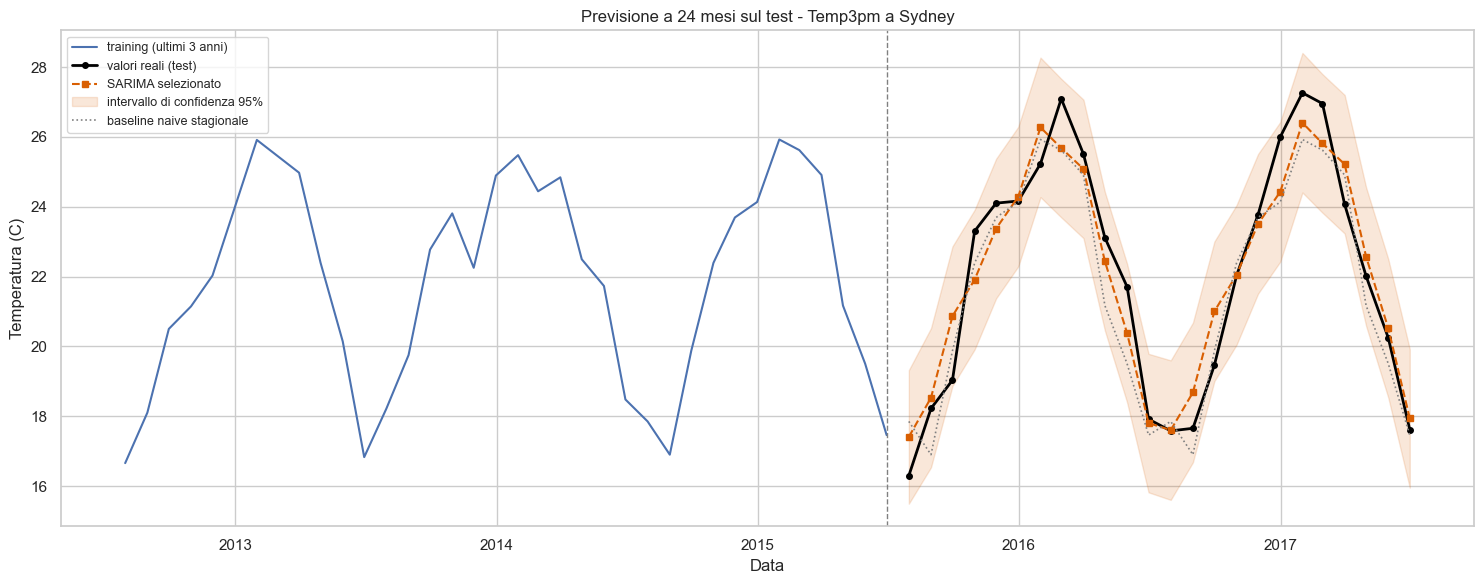

In [164]:
m_fin_train = modelli_train[MODELLO_FINALE]
pred_fin = pred_test[MODELLO_FINALE]

# intervallo di confidenza del modello scelto (per i modelli con esogene deterministiche
# servono le stesse esogene future usate per la previsione)
idx_f = indice_futuro(train, N_TEST)
if MODELLO_FINALE == "AR(1) + dummy mensili + trend":
    ci = m_fin_train.get_forecast(N_TEST, exog=dummy_mesi(idx_f)).conf_int()
elif MODELLO_FINALE.startswith("AR(1) + Fourier"):
    ci = m_fin_train.get_forecast(N_TEST, exog=fourier(idx_f, len(train))).conf_int()
elif MODELLO_FINALE == "SARIMA + esogene previste":
    ex_y = exog_passato(len(train))
    ex_f = pd.DataFrame({c: naive_stagionale(ex_y[c], N_TEST) for c in EXOG_VARS}, index=idx_f)
    ci = m_fin_train.get_forecast(N_TEST, exog=ex_f).conf_int()
else:
    ci = m_fin_train.get_forecast(N_TEST).conf_int()
ci.index = test.index

plt.figure(figsize=(15, 6))
plt.plot(train.index[-36:], train.values[-36:], label="training (ultimi 3 anni)", color="#4C72B0")
plt.plot(test.index, test.values, label="valori reali (test)", color="black", lw=2, marker="o", ms=4)
plt.plot(test.index, pred_fin, label=MODELLO_FINALE, color="#D95F02", ls="--", marker="s", ms=4)
plt.fill_between(test.index, ci.iloc[:, 0], ci.iloc[:, 1], color="#D95F02", alpha=.15,
                 label="intervallo di confidenza 95%")
plt.plot(test.index, pred_test["Baseline naive stagionale"], label="baseline naive stagionale",
         color="grey", ls=":", lw=1.2)
plt.axvline(train.index[-1], color="grey", ls="--", lw=1)
plt.title(f"Previsione a {N_TEST} mesi sul test - {VARIABILE} a {LOCALITA}")
plt.xlabel("Data"); plt.ylabel("Temperatura (C)"); plt.legend(loc="upper left", fontsize=9)
plt.tight_layout(); salva("forecast_test"); plt.show()

### Analisi dell'errore del modello scelto

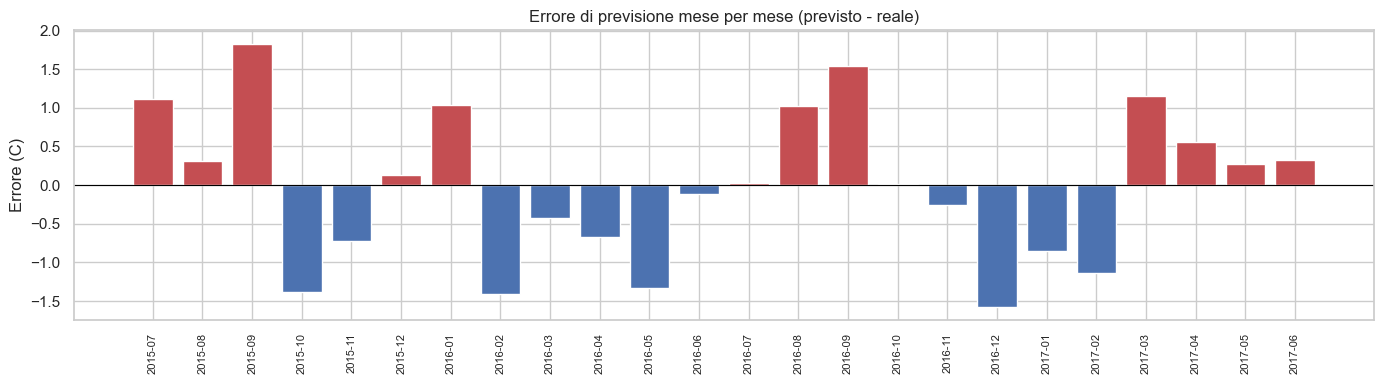

Bias: -0.024 C
Errore massimo: +1.83 C (2015-09)
Sottostime piu' ampie:
Date
2016-12-31   -1.57
2016-02-29   -1.41
2015-10-31   -1.39
2016-05-31   -1.33

Dev. std reali 3.46 | previsioni 2.99 | rapporto 0.86


In [165]:
errori = pd.DataFrame({"reale": test, "previsto": pred_fin})
errori["errore"] = errori["previsto"] - errori["reale"]

plt.figure(figsize=(14, 4))
colori = ["#C44E52" if e > 0 else "#4C72B0" for e in errori["errore"]]
plt.bar(range(len(errori)), errori["errore"], color=colori)
plt.axhline(0, color="black", lw=.8)
plt.xticks(range(len(errori)), [d.strftime("%Y-%m") for d in errori.index], rotation=90, fontsize=8)
plt.title("Errore di previsione mese per mese (previsto - reale)")
plt.ylabel("Errore (C)")
plt.tight_layout(); salva("errore_mensile"); plt.show()

i_max = errori["errore"].abs().idxmax()
print(f"Bias: {errori['errore'].mean():+.3f} C")
print(f"Errore massimo: {errori.loc[i_max, 'errore']:+.2f} C ({i_max:%Y-%m})")
print("Sottostime piu' ampie:")
print(errori["errore"].nsmallest(4).round(2).to_string())
sd_r, sd_p = test.std(), pred_fin.std()
print(f"\nDev. std reali {sd_r:.2f} | previsioni {sd_p:.2f} | rapporto {sd_p / sd_r:.2f}")

## Variabili esogene: scenario realizzabile e oracolo

Il modello con esogene richiede i valori delle covariate nei mesi da prevedere. Si confrontano
due scenari:

- **esogene previste**: le covariate del test sono previste con la regola naïve stagionale,
  usando solo il training. È la previsione realizzabile;
- **oracolo**: si usano i valori reali delle covariate nel test. **Non è una previsione
  realizzabile**, ma un limite superiore che quantifica quanto varrebbero le esogene se fossero
  note in anticipo.

Le esogene del test vengono imputate usando solo il periodo di test, così che nessun valore del
test entri nell'imputazione del training.

Coefficienti del modello con esogene (stimati sul training):
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
intercept       0.0626      0.059      1.065      0.287      -0.053       0.178
Humidity3pm    -0.1036      0.029     -3.618      0.000      -0.160      -0.047
Pressure3pm     0.0214      0.048      0.447      0.655      -0.073       0.115
ar.L1           0.2379      0.131      1.811      0.070      -0.020       0.495
ma.S.L12       -0.9980     37.989     -0.026      0.979     -75.455      73.459
sigma2          0.6445     24.437      0.026      0.979     -47.250      48.539


,MAE,RMSE,MAPE %,Bias
"SARIMA + esogene (oracolo, NON realizzabile)",0.665,0.775,3.022,-0.004
SARIMA + esogene previste,0.848,1.045,3.842,-0.302
SARIMA selezionato (univariato),0.801,0.967,3.634,-0.024
Baseline naive stagionale,0.893,1.074,4.056,-0.478


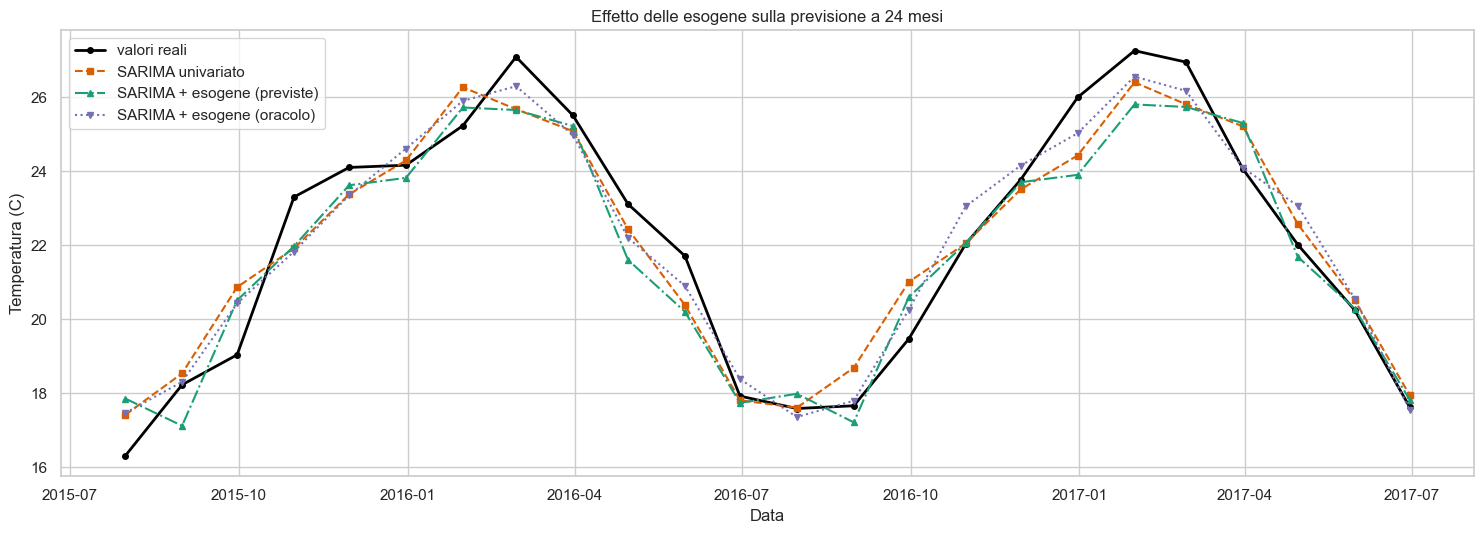

In [166]:
m_exog = modelli_train["SARIMA + esogene previste"]
print("Coefficienti del modello con esogene (stimati sul training):")
print(m_exog.summary().tables[1])

exog_test_reali = exog_raw.iloc[-N_TEST:].interpolate(method="time").ffill().bfill()
assert exog_test_reali.notna().all().all()
pred_oracolo = pd.Series(m_exog.get_forecast(N_TEST, exog=exog_test_reali).predicted_mean.values,
                         index=test.index)

tab_exog = pd.DataFrame({
    "SARIMA + esogene (oracolo, NON realizzabile)": metriche(test, pred_oracolo),
    "SARIMA + esogene previste": metriche(test, pred_test["SARIMA + esogene previste"]),
    "SARIMA selezionato (univariato)": metriche(test, pred_test["SARIMA selezionato"]),
    "Baseline naive stagionale": metriche(test, pred_test["Baseline naive stagionale"]),
}).T.round(3)
display(tab_exog)

plt.figure(figsize=(15, 5.5))
plt.plot(test.index, test.values, label="valori reali", color="black", lw=2, marker="o", ms=4)
plt.plot(test.index, pred_test["SARIMA selezionato"], label="SARIMA univariato",
         color="#D95F02", ls="--", marker="s", ms=4)
plt.plot(test.index, pred_test["SARIMA + esogene previste"], label="SARIMA + esogene (previste)",
         color="#1B9E77", ls="-.", marker="^", ms=4)
plt.plot(test.index, pred_oracolo, label="SARIMA + esogene (oracolo)",
         color="#7570B3", ls=":", marker="v", ms=4)
plt.title(f"Effetto delle esogene sulla previsione a {N_TEST} mesi")
plt.xlabel("Data"); plt.ylabel("Temperatura (C)"); plt.legend()
plt.tight_layout(); salva("confronto_test"); plt.show()

## Previsione dei 12 mesi successivi

Il test ha esaurito la sua funzione: il modello scelto viene riaddestrato sull'**intera serie**
(training imputato e test) con la stessa specificazione, e prevede i 12 mesi successivi.

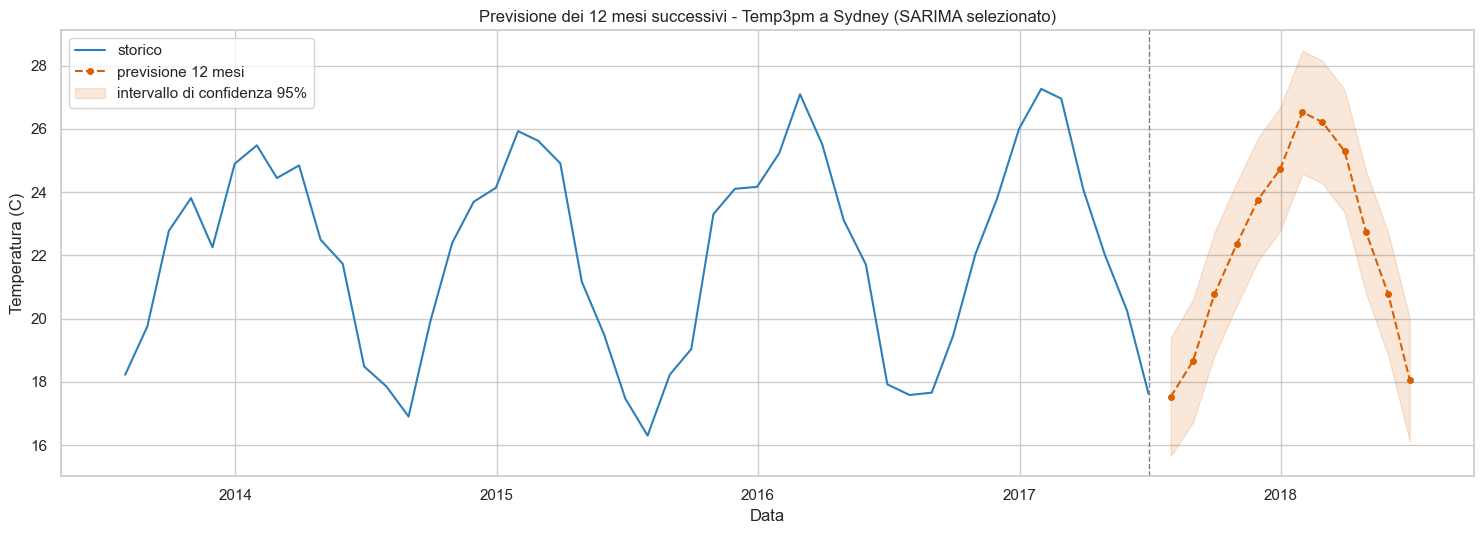

Ampiezza media dell'intervallo: 3.9 C


,Previsione,IC 95% inf,IC 95% sup
2017-07,17.5,15.7,19.4
2017-08,18.7,16.7,20.6
2017-09,20.8,18.8,22.7
2017-10,22.3,20.4,24.3
2017-11,23.8,21.8,25.7
2017-12,24.7,22.8,26.7
2018-01,26.5,24.6,28.5
2018-02,26.2,24.3,28.1
2018-03,25.3,23.4,27.2
2018-04,22.7,20.8,24.7


In [167]:
pred_fut, m_full, _ = adatta_e_prevedi(MODELLO_FINALE, serie, N_FUTURO)
idx_fut = indice_futuro(serie, N_FUTURO)

if MODELLO_FINALE == "AR(1) + dummy mensili + trend":
    ci_fut = m_full.get_forecast(N_FUTURO, exog=dummy_mesi(idx_fut)).conf_int()
elif MODELLO_FINALE.startswith("AR(1) + Fourier"):
    ci_fut = m_full.get_forecast(N_FUTURO, exog=fourier(idx_fut, len(serie))).conf_int()
elif MODELLO_FINALE == "SARIMA + esogene previste":
    ex_y = exog_passato(len(serie))
    ex_f = pd.DataFrame({c: naive_stagionale(ex_y[c], N_FUTURO) for c in EXOG_VARS}, index=idx_fut)
    ci_fut = m_full.get_forecast(N_FUTURO, exog=ex_f).conf_int()
else:
    ci_fut = m_full.get_forecast(N_FUTURO).conf_int()
pred_fut = pd.Series(pred_fut, index=idx_fut)
ci_fut.index = idx_fut

plt.figure(figsize=(15, 5.5))
plt.plot(serie.index[-48:], serie.values[-48:], label="storico", color="#2C7FB8")
plt.plot(pred_fut.index, pred_fut.values, label=f"previsione {N_FUTURO} mesi",
         color="#D95F02", ls="--", marker="o", ms=4)
plt.fill_between(pred_fut.index, ci_fut.iloc[:, 0], ci_fut.iloc[:, 1], color="#D95F02",
                 alpha=.15, label="intervallo di confidenza 95%")
plt.axvline(serie.index[-1], color="grey", ls="--", lw=1)
plt.title(f"Previsione dei {N_FUTURO} mesi successivi - {VARIABILE} a {LOCALITA} ({MODELLO_FINALE})")
plt.xlabel("Data"); plt.ylabel("Temperatura (C)"); plt.legend()
plt.tight_layout(); salva("previsione_futura"); plt.show()

tab_fut = pd.DataFrame({"Previsione": pred_fut, "IC 95% inf": ci_fut.iloc[:, 0],
                        "IC 95% sup": ci_fut.iloc[:, 1]}).round(1)
tab_fut.index = tab_fut.index.strftime("%Y-%m")
print(f"Ampiezza media dell'intervallo: {(ci_fut.iloc[:, 1] - ci_fut.iloc[:, 0]).mean():.1f} C")
tab_fut

## Riepilogo dei numeri principali

La cella raccoglie i valori da riportare nella relazione, così che il testo resti allineato
all'ultima esecuzione.

In [168]:
print(f"Training: {len(train)} mesi | test: {len(test)} mesi")
print(f"Ciclo stagionale {ampiezza:.1f} C | residuo della decomposizione {dec.resid.std():.2f} C")
print(f"Trend scelto: '{TREND}' (AIC: n={tab_trend.loc['n','AIC']}, c={tab_trend.loc['c','AIC']})")
print(f"Ordini: {ORDER}{SORDER}")
print(f"Modello scelto in validazione: {MODELLO_FINALE}")
print("\nValidazione a origine mobile (MAE medio):")
print(tab_cv["MAE medio"].round(3).to_string())
print("\nTest (MAE):")
print(tab_test["MAE"].sort_values().round(3).to_string())
print(f"\nOracolo esogene: MAE {tab_exog.iloc[0]['MAE']:.3f}")

Training: 89 mesi | test: 24 mesi
Ciclo stagionale 8.8 C | residuo della decomposizione 0.82 C
Trend scelto: 'c' (AIC: n=238.6, c=236.5)
Ordini: (1, 0, 0)(0, 1, 1, 12)
Modello scelto in validazione: SARIMA selezionato

Validazione a origine mobile (MAE medio):
AR(1) + Fourier K=2 senza trend    0.908
SARIMA selezionato                 0.913
SARIMA + esogene previste          0.913
AR(1) + dummy mensili + trend      0.914
AR(1) + Fourier K=2 + trend        0.920
SARIMA senza costante              0.965
Baseline naive stagionale          1.173

Test (MAE):
AR(1) + Fourier K=2 + trend        0.769
SARIMA selezionato                 0.801
AR(1) + dummy mensili + trend      0.812
SARIMA + esogene previste          0.848
Baseline naive stagionale          0.893
AR(1) + Fourier K=2 senza trend    0.908
SARIMA senza costante              0.995

Oracolo esogene: MAE 0.665
